## **Phần 3 & Phần 4 — TransformerEncoder tự hiện thực, ViT và các kiến trúc mở rộng**

### **Mục tiêu thực hiện**

- Tự hiện thực khối TransformerEncoder bằng các phép toán cơ bản của PyTorch (`Linear`, `LayerNorm`, `einsum`).
- Xây dựng ViT dựa trên khối tự hiện thực và so sánh với ViT dùng khối có sẵn của PyTorch.
- Mở rộng sang các kiến trúc kết hợp (CNN + Transformer) và các cách embed/tokenize ảnh khác nhau trên CIFAR-10.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import copy
import os
import random
import time

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# De demo nhanh: FAST_RUN=True. Bao cao cuoi ky co the doi False.
FAST_RUN = False
BATCH_SIZE = 128
NUM_WORKERS = 0
LEARNING_RATE = 1e-3
PART3_EPOCHS = 2 if FAST_RUN else 20

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


Device: cuda


## **Thiết lập dữ liệu CIFAR-10**

In [5]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

root_data = "./data"
cifar_folder = os.path.join(root_data, "cifar-10-batches-py")
required_files = [
    "batches.meta",
    "data_batch_1",
    "data_batch_2",
    "data_batch_3",
    "data_batch_4",
    "data_batch_5",
    "test_batch",
]
local_cifar_ready = os.path.isdir(cifar_folder) and all(
    os.path.exists(os.path.join(cifar_folder, f)) for f in required_files
)

if local_cifar_ready:
    print("CIFAR-10 da co san o local, bo qua download.")
    full_train_dataset = datasets.CIFAR10(
        root=root_data, train=True, download=False, transform=train_transform
    )
    test_dataset = datasets.CIFAR10(
        root=root_data, train=False, download=False, transform=test_transform
    )
else:
    print("Chua tim thay day du file local, se download CIFAR-10...")
    full_train_dataset = datasets.CIFAR10(
        root=root_data, train=True, download=True, transform=train_transform
    )
    test_dataset = datasets.CIFAR10(
        root=root_data, train=False, download=True, transform=test_transform
    )

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

if FAST_RUN:
    train_dataset = Subset(train_dataset, range(min(2048, len(train_dataset))))
    val_dataset = Subset(val_dataset, range(min(512, len(val_dataset))))
    test_dataset = Subset(test_dataset, range(min(512, len(test_dataset))))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train={len(train_dataset)} | Val={len(val_dataset)} | Test={len(test_dataset)}")


Chua tim thay day du file local, se download CIFAR-10...


100%|██████████| 170M/170M [00:03<00:00, 44.0MB/s]


Train=40000 | Val=10000 | Test=10000


## **Hàm huấn luyện, đánh giá và trực quan hóa**

In [6]:
def evaluate(model, loader, criterion=None):
    model.eval()
    all_preds, all_labels = [], []
    running_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)

            if criterion is not None:
                running_loss += criterion(logits, labels).item()
                n_batches += 1

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    avg_loss = (running_loss / max(n_batches, 1)) if criterion is not None else None
    acc = float((all_preds == all_labels).mean())
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": avg_loss,
        "acc": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "cm": cm,
    }


def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3, weight_decay=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
    }
    best_f1 = -1.0
    best_state = None

    start = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        val_metrics = evaluate(model, val_loader, criterion=criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["acc"])
        history["val_f1"].append(val_metrics["f1"])

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['acc']:.4f} | val_f1={val_metrics['f1']:.4f}"
        )

        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())

    train_time = time.perf_counter() - start

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, train_time


def run_experiment(models, train_loader, val_loader, test_loader, epochs, lr):
    rows = []
    histories = {}
    conf_mats = {}

    for name, model in models.items():
        print(f"\n===== Training: {name} =====")
        best_model, history, train_time = train_model(
            model, train_loader, val_loader, epochs=epochs, lr=lr
        )

        test_metrics = evaluate(best_model, test_loader, criterion=nn.CrossEntropyLoss())

        rows.append({
            "Model": name,
            "Loss": test_metrics["loss"],
            "Accuracy": test_metrics["acc"],
            "Precision": test_metrics["precision"],
            "Recall": test_metrics["recall"],
            "F1-score": test_metrics["f1"],
            "Train time (s)": train_time,
        })

        histories[name] = history
        conf_mats[name] = test_metrics["cm"]

    df = pd.DataFrame(rows).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
    return df, histories, conf_mats


def plot_histories(histories, title_prefix=""):
    for name, hist in histories.items():
        epochs = range(1, len(hist["train_loss"]) + 1)
        plt.figure(figsize=(15, 4))

        plt.subplot(1, 3, 1)
        plt.plot(epochs, hist["train_loss"], marker="o", label="train")
        plt.plot(epochs, hist["val_loss"], marker="o", label="val")
        plt.title(f"{title_prefix}{name} - Loss")
        plt.xlabel("Epoch")
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(epochs, hist["val_acc"], marker="o")
        plt.title(f"{title_prefix}{name} - Val Accuracy")
        plt.xlabel("Epoch")

        plt.subplot(1, 3, 3)
        plt.plot(epochs, hist["val_f1"], marker="o")
        plt.title(f"{title_prefix}{name} - Val F1")
        plt.xlabel("Epoch")

        plt.tight_layout()
        plt.show()


def plot_confusion_matrices(conf_mats, class_names):
    for name, cm in conf_mats.items():
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
        )
        plt.title(f"{name} - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.xticks(rotation=45, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()


## **Phần 3 — Tự hiện thực TransformerEncoder và ViT**

### **1. Yêu cầu đề bài (mục 3.3)**

- Các class `ScratchMHSA`, `ScratchEncoderBlock`, `ScratchTransformerEncoder` bên dưới
  **không dùng** `nn.TransformerEncoderLayer` và `nn.TransformerEncoder`.
- Chỉ sử dụng phép toán cơ bản: `Linear`, `LayerNorm`, `einsum`, `softmax`, `dropout`.

### **2. Đối chiếu yêu cầu đã thực hiện**

- Đã tự hiện thực khối TransformerEncoder từ primitive PyTorch.
- Đã xây dựng ViT dựa trên khối tự hiện thực.
- Đã huấn luyện, đánh giá và so sánh với ViT dùng khối có sẵn (accuracy, loss, thời gian huấn luyện).

In [7]:
class ScratchMHSA(nn.Module):
    def __init__(self, dim, num_heads=8, dropout=0.1):
        super().__init__()
        assert dim % num_heads == 0, "dim must be divisible by num_heads"
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, N, D)
        bsz, n_tokens, _ = x.shape

        qkv = self.qkv(x)
        qkv = qkv.view(bsz, n_tokens, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # (B, H, N, Hd)

        attn = torch.einsum("bhid,bhjd->bhij", q, k) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)

        out = torch.einsum("bhij,bhjd->bhid", attn, v)
        out = out.transpose(1, 2).contiguous().view(bsz, n_tokens, self.dim)
        out = self.proj(out)
        return out


class ScratchFFN(nn.Module):
    def __init__(self, dim, mlp_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class ScratchEncoderBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = ScratchMHSA(dim, num_heads=num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = ScratchFFN(dim, mlp_dim=mlp_dim, dropout=dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class ScratchTransformerEncoder(nn.Module):
    def __init__(self, depth, dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            ScratchEncoderBlock(dim, num_heads, mlp_dim, dropout=dropout)
            for _ in range(depth)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class ViTScratch(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        num_classes=10,
        dim=128,
        depth=6,
        num_heads=8,
        mlp_dim=256,
        dropout=0.1,
    ):
        super().__init__()
        assert img_size % patch_size == 0

        num_patches = (img_size // patch_size) ** 2

        self.patch_embed = nn.Conv2d(3, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.dropout = nn.Dropout(dropout)

        self.encoder = ScratchTransformerEncoder(
            depth=depth,
            dim=dim,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout=dropout,
        )

        self.head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, num_classes))

    def forward(self, x):
        bsz = x.size(0)
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)

        cls = self.cls_token.expand(bsz, -1, -1)
        x = torch.cat([cls, x], dim=1)

        x = x + self.pos_embed
        x = self.dropout(x)

        x = self.encoder(x)
        x = x[:, 0]
        return self.head(x)


class ViTBuiltin(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        num_classes=10,
        dim=128,
        depth=6,
        num_heads=8,
        mlp_dim=256,
        dropout=0.1,
    ):
        super().__init__()
        assert img_size % patch_size == 0

        num_patches = (img_size // patch_size) ** 2

        self.patch_embed = nn.Conv2d(3, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.dropout = nn.Dropout(dropout)

        # Baseline co san cua PyTorch de so sanh
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, num_classes))

    def forward(self, x):
        bsz = x.size(0)
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)

        cls = self.cls_token.expand(bsz, -1, -1)
        x = torch.cat([cls, x], dim=1)

        x = x + self.pos_embed
        x = self.dropout(x)

        x = self.encoder(x)
        x = x[:, 0]
        return self.head(x)


with torch.no_grad():
    dummy = torch.randn(4, 3, 32, 32)
    print("ViTScratch output shape:", ViTScratch()(dummy).shape)
    print("ViTBuiltin output shape:", ViTBuiltin()(dummy).shape)


ViTScratch output shape: torch.Size([4, 10])
ViTBuiltin output shape: torch.Size([4, 10])


### **2.1. Giải thích kiến trúc và trực quan hóa thông số (Phần 3)**

**Kiến trúc ViT tự hiện thực (tóm tắt):**
- Ảnh đầu vào được chia patch bằng `Conv2d(stride=patch_size)`.
- Ghép thêm `CLS token`, cộng `Positional Embedding`.
- Đưa qua chuỗi `ScratchTransformerEncoder` (MHSA + FFN + residual + LayerNorm).
- Lấy đặc trưng tại `CLS token` để phân loại.

**Mục tiêu trực quan hóa bên dưới:**
- So sánh số lượng tham số giữa `ViT_scratch` và `ViT_builtin`.
- So sánh số token theo kích thước patch.
- Quan sát ví dụ patch hóa ảnh đầu vào.

,Model,Trainable params,Trainable params (M)
0,ViT_scratch,811146,0.811146
1,ViT_builtin,811146,0.811146


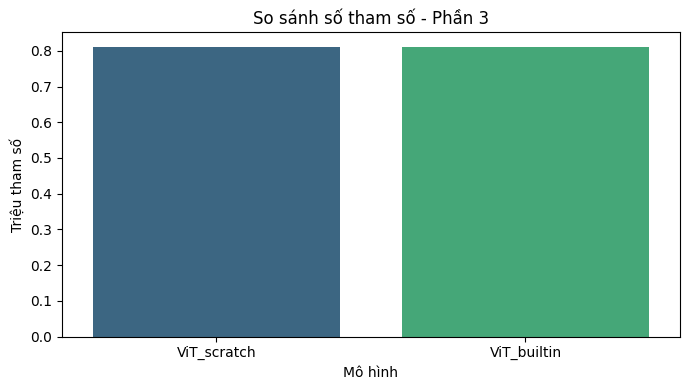

,Patch size,Số token patch (N)
0,2,256
1,4,64
2,8,16
3,16,4


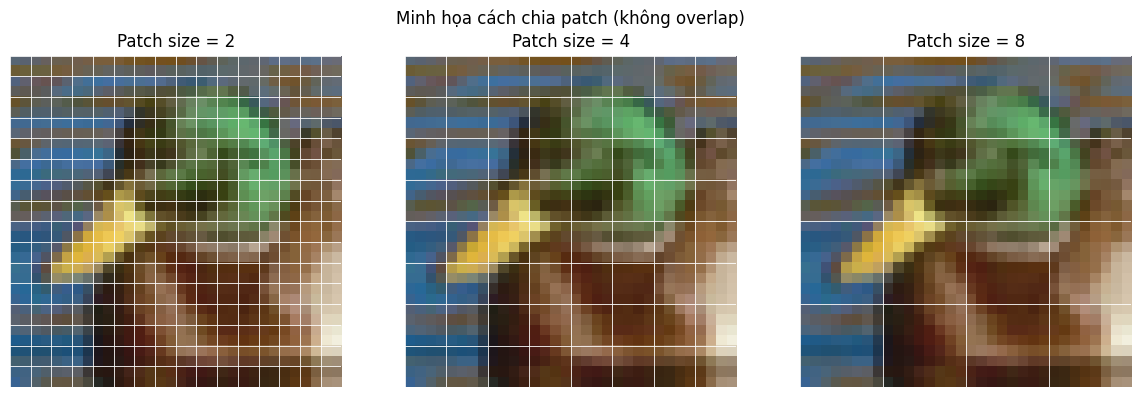

In [8]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

vit_scratch_tmp = ViTScratch()
vit_builtin_tmp = ViTBuiltin()

part3_param_df = pd.DataFrame(
    [
        {"Model": "ViT_scratch", "Trainable params": count_params(vit_scratch_tmp)},
        {"Model": "ViT_builtin", "Trainable params": count_params(vit_builtin_tmp)},
    ]
)
part3_param_df["Trainable params (M)"] = part3_param_df["Trainable params"] / 1e6

display(part3_param_df)

plt.figure(figsize=(7, 4))
sns.barplot(
    data=part3_param_df, x="Model", y="Trainable params (M)", hue="Model",
    dodge=False, legend=False, palette="viridis"
)
plt.title("So sánh số tham số - Phần 3")
plt.ylabel("Triệu tham số")
plt.xlabel("Mô hình")
plt.tight_layout()
plt.show()

img_size = 32
patch_choices = [2, 4, 8, 16]
token_df = pd.DataFrame(
    {
        "Patch size": patch_choices,
        "Số token patch (N)": [(img_size // p) ** 2 for p in patch_choices],
    }
)
display(token_df)

# Minh họa patch hóa trên 1 ảnh mẫu
sample_images, _ = next(iter(train_loader))
sample_img = sample_images[0].detach().cpu()
sample_img = sample_img * 0.5 + 0.5  # unnormalize về [0,1] gần đúng
sample_img = sample_img.clamp(0, 1)

def draw_patch_grid(ax, img, patch_size, title):
    np_img = img.permute(1, 2, 0).numpy()
    ax.imshow(np_img)
    h, w = np_img.shape[:2]
    for y in range(0, h, patch_size):
        ax.axhline(y=y - 0.5, color="white", linewidth=0.6)
    for x in range(0, w, patch_size):
        ax.axvline(x=x - 0.5, color="white", linewidth=0.6)
    ax.set_title(title)
    ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
draw_patch_grid(axes[0], sample_img, 2, "Patch size = 2")
draw_patch_grid(axes[1], sample_img, 4, "Patch size = 4")
draw_patch_grid(axes[2], sample_img, 8, "Patch size = 8")
plt.suptitle("Minh họa cách chia patch (không overlap)")
plt.tight_layout()
plt.show()

### **3. Huấn luyện, đánh giá và so sánh mô hình (Phần 3)**

In [9]:
part3_models = {
    "ViT_builtin": ViTBuiltin(),
    "ViT_scratch": ViTScratch(),
}

part3_df, part3_histories, part3_conf_mats = run_experiment(
    part3_models,
    train_loader,
    val_loader,
    test_loader,
    epochs=PART3_EPOCHS,
    lr=LEARNING_RATE,
)

print("\n=== Kết quả Phần 3 (test) ===")
print(part3_df)



===== Training: ViT_builtin =====
Epoch 01/20 | train_loss=1.8713 | val_loss=1.6170 | val_acc=0.4007 | val_f1=0.3819
Epoch 02/20 | train_loss=1.5709 | val_loss=1.4532 | val_acc=0.4755 | val_f1=0.4645
Epoch 03/20 | train_loss=1.4433 | val_loss=1.3491 | val_acc=0.5179 | val_f1=0.5103
Epoch 04/20 | train_loss=1.3566 | val_loss=1.2689 | val_acc=0.5441 | val_f1=0.5456
Epoch 05/20 | train_loss=1.2805 | val_loss=1.1981 | val_acc=0.5704 | val_f1=0.5697
Epoch 06/20 | train_loss=1.2333 | val_loss=1.1558 | val_acc=0.5919 | val_f1=0.5895
Epoch 07/20 | train_loss=1.1876 | val_loss=1.1411 | val_acc=0.5970 | val_f1=0.5935
Epoch 08/20 | train_loss=1.1592 | val_loss=1.1094 | val_acc=0.6074 | val_f1=0.6026
Epoch 09/20 | train_loss=1.1226 | val_loss=1.1073 | val_acc=0.6135 | val_f1=0.6064
Epoch 10/20 | train_loss=1.0884 | val_loss=1.0745 | val_acc=0.6206 | val_f1=0.6158
Epoch 11/20 | train_loss=1.0652 | val_loss=1.0709 | val_acc=0.6250 | val_f1=0.6257
Epoch 12/20 | train_loss=1.0377 | val_loss=1.0669 | 

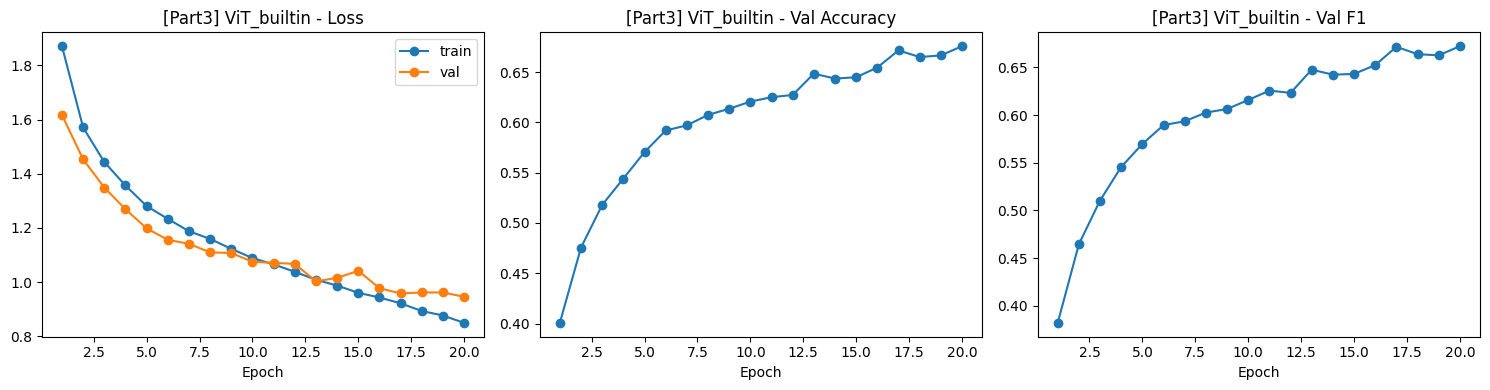

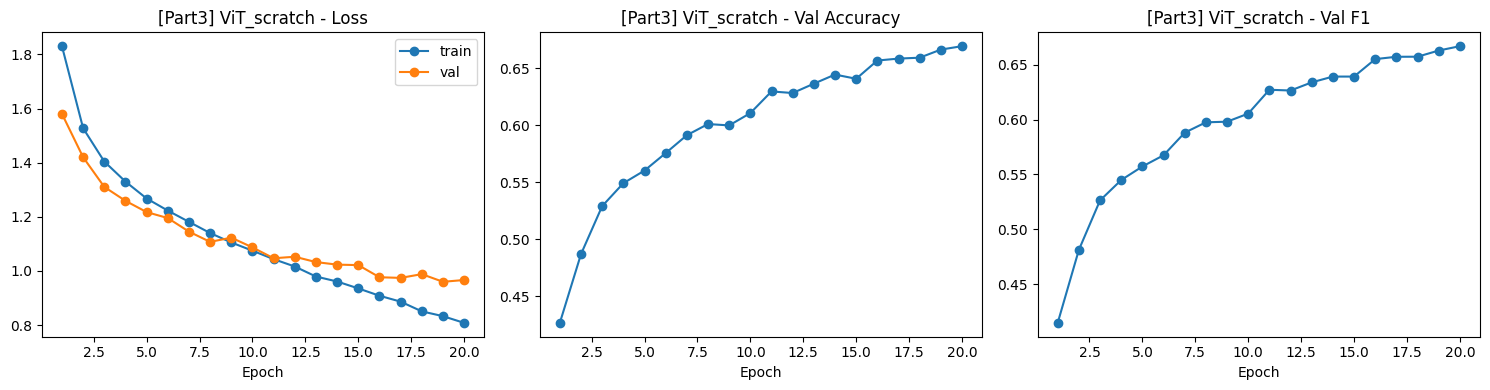

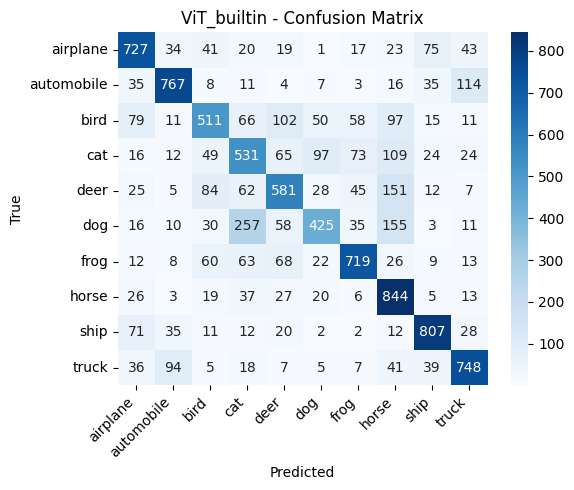

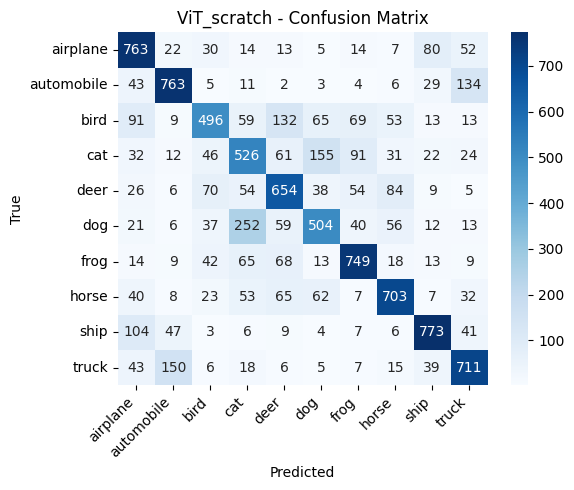

In [10]:
plot_histories(part3_histories, title_prefix="[Part3] ")
plot_confusion_matrices(part3_conf_mats, CLASS_NAMES)


### **4. Nhận xét kết quả Phần 3**

In [11]:
best_row = part3_df.iloc[0]
print(
    f"Mô hình tốt hơn trên test: {best_row['Model']} | "
    f"loss={best_row['Loss']:.4f}, acc={best_row['Accuracy']:.4f}, "
    f"train_time={best_row['Train time (s)']:.2f}s"
)
print("Nhận xét: ViT tự hiện thực cho phép kiểm soát chi tiết bên trong Transformer,")
print("nhưng thông thường cần tinh chỉnh kỹ hơn để đạt hiệu năng ổn định như khối có sẵn.")

Mô hình tốt hơn trên test: ViT_builtin | loss=0.9525, acc=0.6660, train_time=938.12s
Nhận xét: ViT tự hiện thực cho phép kiểm soát chi tiết bên trong Transformer,
nhưng thông thường cần tinh chỉnh kỹ hơn để đạt hiệu năng ổn định như khối có sẵn.


## **Phần 4 — Kiến trúc kết hợp và các cách embedding ảnh khác nhau**

### **1. Yêu cầu đề bài (mục 3.4)**

- Có ít nhất 2-3 hướng xây dựng khác nhau.
- Ví dụ: CNN + Transformer, tokenizer/embed khác nhau (patch overlap, patch size khác),
  và hướng biểu diễn token theo chiều C thay vì H*W.
- Huấn luyện, đánh giá và so sánh kết quả theo cùng tập dữ liệu.

### **2. Định nghĩa các kiến trúc mở rộng (Phần 4)**

Các mô hình được triển khai trong phần này gồm:
- **Hybrid CNN + Transformer**: CNN trích đặc trưng trước, sau đó đưa chuỗi token qua Transformer.
- **ViT với overlap patch**: dùng `nn.Unfold` để tạo patch chồng lấp.
- **ViT patch size khác**: so sánh với patch lớn hơn (`patch_size=8`).
- **Channel-token Transformer**: biểu diễn token theo chiều kênh C thay vì H*W.

In [12]:
PART4_EPOCHS = 2 if FAST_RUN else 15

class HybridCNNTransformer(nn.Module):
    """CNN backbone -> token sequence -> Scratch Transformer encoder."""
    def __init__(
        self,
        num_classes=10,
        img_size=32,
        dim=128,
        depth=4,
        num_heads=8,
        mlp_dim=256,
        dropout=0.1,
    ):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32 -> 16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16 -> 8
        )
        self.proj = nn.Conv2d(128, dim, kernel_size=1)

        fmap_size = img_size // 4
        n_tokens = fmap_size * fmap_size

        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.randn(1, n_tokens + 1, dim))
        self.dropout = nn.Dropout(dropout)

        self.encoder = ScratchTransformerEncoder(
            depth=depth,
            dim=dim,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout=dropout,
        )
        self.head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, num_classes))

    def forward(self, x):
        bsz = x.size(0)
        x = self.backbone(x)
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)

        cls = self.cls_token.expand(bsz, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.dropout(x + self.pos_embed)

        x = self.encoder(x)
        return self.head(x[:, 0])


class ViTScratchOverlap(nn.Module):
    """Patch tokenizer with overlap using nn.Unfold."""
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        stride=2,
        num_classes=10,
        dim=128,
        depth=6,
        num_heads=8,
        mlp_dim=256,
        dropout=0.1,
    ):
        super().__init__()
        assert patch_size <= img_size
        assert stride > 0

        self.unfold = nn.Unfold(kernel_size=patch_size, stride=stride)
        patch_dim = 3 * patch_size * patch_size
        num_steps = ((img_size - patch_size) // stride) + 1
        num_patches = num_steps * num_steps

        self.patch_proj = nn.Linear(patch_dim, dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.dropout = nn.Dropout(dropout)

        self.encoder = ScratchTransformerEncoder(
            depth=depth,
            dim=dim,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout=dropout,
        )
        self.head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, num_classes))

    def forward(self, x):
        bsz = x.size(0)
        patches = self.unfold(x).transpose(1, 2)  # (B, N, patch_dim)
        x = self.patch_proj(patches)

        cls = self.cls_token.expand(bsz, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.dropout(x + self.pos_embed)

        x = self.encoder(x)
        return self.head(x[:, 0])


class ChannelTokenTransformer(nn.Module):
    """Tokenize by channel dimension C (instead of spatial H*W patches)."""
    def __init__(
        self,
        img_size=32,
        in_channels=3,
        num_classes=10,
        dim=128,
        depth=4,
        num_heads=8,
        mlp_dim=256,
        dropout=0.1,
    ):
        super().__init__()
        self.token_proj = nn.Linear(img_size * img_size, dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.randn(1, in_channels + 1, dim))
        self.dropout = nn.Dropout(dropout)

        self.encoder = ScratchTransformerEncoder(
            depth=depth,
            dim=dim,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout=dropout,
        )
        self.head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, num_classes))

    def forward(self, x):
        bsz = x.size(0)
        x = x.view(bsz, x.size(1), -1)  # (B, C, H*W)
        x = self.token_proj(x)          # (B, C, D)

        cls = self.cls_token.expand(bsz, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.dropout(x + self.pos_embed)

        x = self.encoder(x)
        return self.head(x[:, 0])


with torch.no_grad():
    dummy = torch.randn(4, 3, 32, 32)
    print("HybridCNNTransformer output shape:", HybridCNNTransformer()(dummy).shape)
    print("ViTScratchOverlap output shape:", ViTScratchOverlap()(dummy).shape)
    print("ChannelTokenTransformer output shape:", ChannelTokenTransformer()(dummy).shape)

HybridCNNTransformer output shape: torch.Size([4, 10])
ViTScratchOverlap output shape: torch.Size([4, 10])
ChannelTokenTransformer output shape: torch.Size([4, 10])


### **2.1. Giải thích biểu diễn token và trực quan hóa thông số (Phần 4)**

**Ý tưởng so sánh:**
- Cùng dữ liệu CIFAR-10 nhưng thay đổi cách tạo token đầu vào cho Transformer.
- Kiểm tra trade-off giữa số token, chi phí tham số và kết quả phân loại.

**Các biểu đồ bên dưới thể hiện:**
- Số token tạo ra bởi từng chiến lược biểu diễn.
- Tổng số tham số trainable của từng mô hình.
- Minh họa trực quan tokenization: patch thường, overlap patch và channel-token.

,Model,Tokenization,So token (khong CLS),Embedding dim,Do sau encoder,Trainable params (M)
0,Hybrid_CNN_Transformer,Feature map 8x8 + CLS,64,128,4,0.632074
1,ViT_overlap_patch,"Patch 4x4, stride=2 (overlap)",225,128,6,0.831754
2,ViT_patch8_nonoverlap,"Patch 8x8, stride=8",16,128,6,0.823434
3,Transformer_channel_tokens,Token theo kenh C=3,3,128,4,0.663306


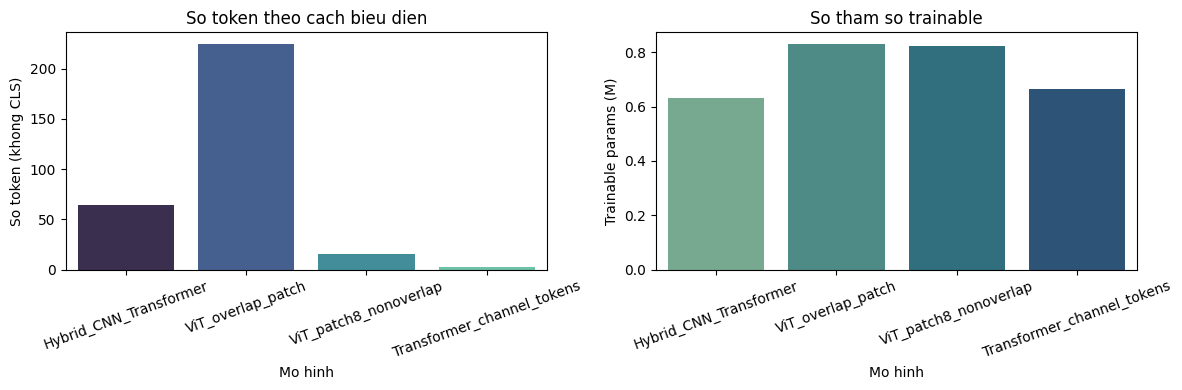

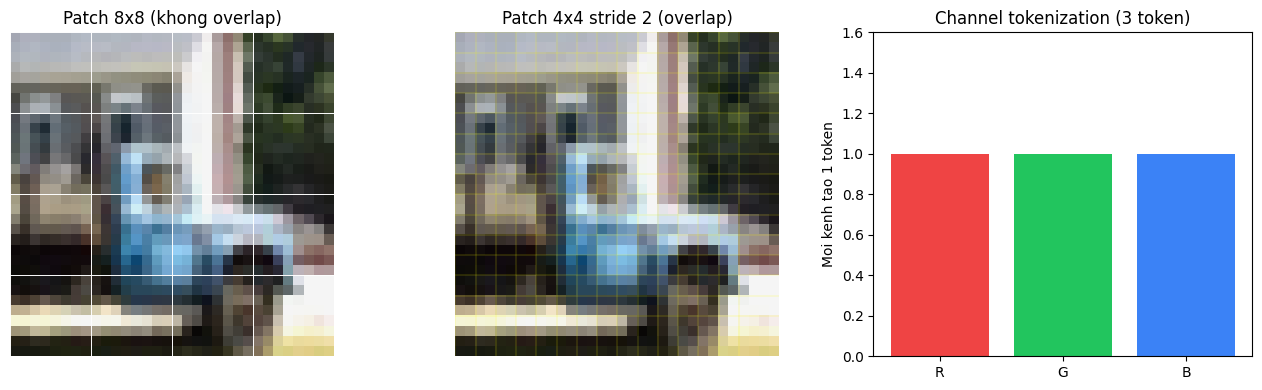

In [13]:
# Bang thong so bieu dien cho cac mo hinh Phan 4
if "count_params" not in globals():
    def count_params(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

part4_repr_df = pd.DataFrame(
    [
        {
            "Model": "Hybrid_CNN_Transformer",
            "Tokenization": "Feature map 8x8 + CLS",
            "So token (khong CLS)": 8 * 8,
            "Embedding dim": 128,
            "Do sau encoder": 4,
            "Trainable params (M)": count_params(HybridCNNTransformer()) / 1e6,
        },
        {
            "Model": "ViT_overlap_patch",
            "Tokenization": "Patch 4x4, stride=2 (overlap)",
            "So token (khong CLS)": ((32 - 4) // 2 + 1) ** 2,
            "Embedding dim": 128,
            "Do sau encoder": 6,
            "Trainable params (M)": count_params(ViTScratchOverlap(patch_size=4, stride=2)) / 1e6,
        },
        {
            "Model": "ViT_patch8_nonoverlap",
            "Tokenization": "Patch 8x8, stride=8",
            "So token (khong CLS)": (32 // 8) ** 2,
            "Embedding dim": 128,
            "Do sau encoder": 6,
            "Trainable params (M)": count_params(ViTScratch(patch_size=8)) / 1e6,
        },
        {
            "Model": "Transformer_channel_tokens",
            "Tokenization": "Token theo kenh C=3",
            "So token (khong CLS)": 3,
            "Embedding dim": 128,
            "Do sau encoder": 4,
            "Trainable params (M)": count_params(ChannelTokenTransformer()) / 1e6,
        },
    ]
)
display(part4_repr_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(
    data=part4_repr_df, x="Model", y="So token (khong CLS)", hue="Model",
    dodge=False, legend=False, palette="mako", ax=axes[0]
)
axes[0].set_title("So token theo cach bieu dien")
axes[0].set_xlabel("Mo hinh")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=part4_repr_df, x="Model", y="Trainable params (M)", hue="Model",
    dodge=False, legend=False, palette="crest", ax=axes[1]
)
axes[1].set_title("So tham so trainable")
axes[1].set_xlabel("Mo hinh")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Minh hoa tokenization tren cung 1 anh
sample_images2, _ = next(iter(train_loader))
sample_img2 = sample_images2[0].detach().cpu() * 0.5 + 0.5
sample_img2 = sample_img2.clamp(0, 1)
np_img2 = sample_img2.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Non-overlap patch 8x8
axes[0].imshow(np_img2)
for y in range(0, 32, 8):
    axes[0].axhline(y=y - 0.5, color="white", linewidth=0.7)
for x in range(0, 32, 8):
    axes[0].axvline(x=x - 0.5, color="white", linewidth=0.7)
axes[0].set_title("Patch 8x8 (khong overlap)")
axes[0].axis("off")

# Overlap patch 4x4 stride 2
axes[1].imshow(np_img2)
for y in range(0, 32 - 4 + 1, 2):
    axes[1].axhline(y=y - 0.5, color="yellow", linewidth=0.3, alpha=0.6)
for x in range(0, 32 - 4 + 1, 2):
    axes[1].axvline(x=x - 0.5, color="yellow", linewidth=0.3, alpha=0.6)
axes[1].set_title("Patch 4x4 stride 2 (overlap)")
axes[1].axis("off")

# Channel tokens: 3 tokens tu 3 kenh
axes[2].bar(["R", "G", "B"], [1, 1, 1], color=["#ef4444", "#22c55e", "#3b82f6"])
axes[2].set_ylim(0, 1.6)
axes[2].set_title("Channel tokenization (3 token)")
axes[2].set_ylabel("Moi kenh tao 1 token")

plt.tight_layout()
plt.show()

### **3. Huấn luyện, đánh giá và so sánh mô hình (Phần 4)**

In [14]:
part4_models = {
    "Hybrid_CNN_Transformer": HybridCNNTransformer(),
    "ViT_overlap_patch": ViTScratchOverlap(patch_size=4, stride=2),
    "ViT_patch8_nonoverlap": ViTScratch(patch_size=8),
    "Transformer_channel_tokens": ChannelTokenTransformer(),
}

part4_df, part4_histories, part4_conf_mats = run_experiment(
    part4_models,
    train_loader,
    val_loader,
    test_loader,
    epochs=PART4_EPOCHS,
    lr=LEARNING_RATE,
 )

print("\n=== Kết quả Phần 4 (test) ===")
print(part4_df)


===== Training: Hybrid_CNN_Transformer =====
Epoch 01/15 | train_loss=1.7408 | val_loss=1.4136 | val_acc=0.4888 | val_f1=0.4766
Epoch 02/15 | train_loss=1.3588 | val_loss=1.2151 | val_acc=0.5706 | val_f1=0.5701
Epoch 03/15 | train_loss=1.1907 | val_loss=1.1368 | val_acc=0.6002 | val_f1=0.5918
Epoch 04/15 | train_loss=1.0730 | val_loss=0.9925 | val_acc=0.6511 | val_f1=0.6458
Epoch 05/15 | train_loss=0.9871 | val_loss=0.9407 | val_acc=0.6694 | val_f1=0.6673
Epoch 06/15 | train_loss=0.9295 | val_loss=0.9168 | val_acc=0.6727 | val_f1=0.6732
Epoch 07/15 | train_loss=0.8693 | val_loss=0.8619 | val_acc=0.6950 | val_f1=0.6928
Epoch 08/15 | train_loss=0.8247 | val_loss=0.8239 | val_acc=0.7054 | val_f1=0.7066
Epoch 09/15 | train_loss=0.7798 | val_loss=0.8082 | val_acc=0.7165 | val_f1=0.7149
Epoch 10/15 | train_loss=0.7492 | val_loss=0.7608 | val_acc=0.7330 | val_f1=0.7324
Epoch 11/15 | train_loss=0.7139 | val_loss=0.7395 | val_acc=0.7417 | val_f1=0.7421
Epoch 12/15 | train_loss=0.6774 | val_los

### **4. Nhận xét kết quả Phần 4**

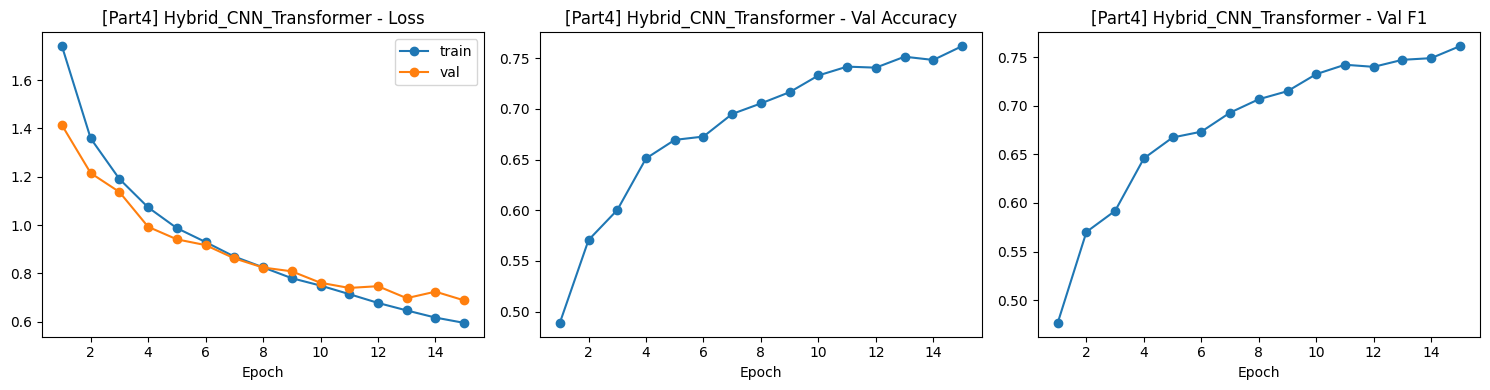

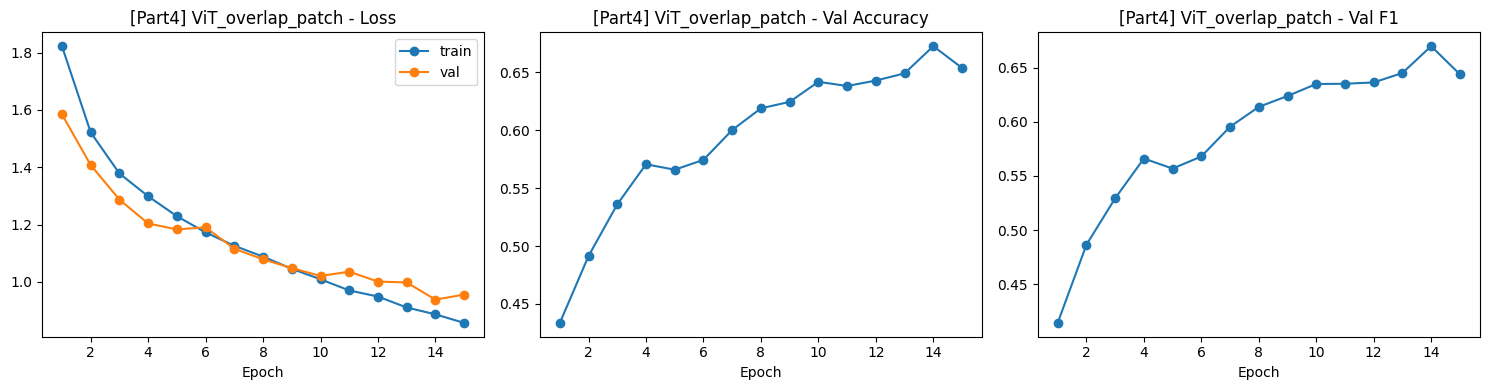

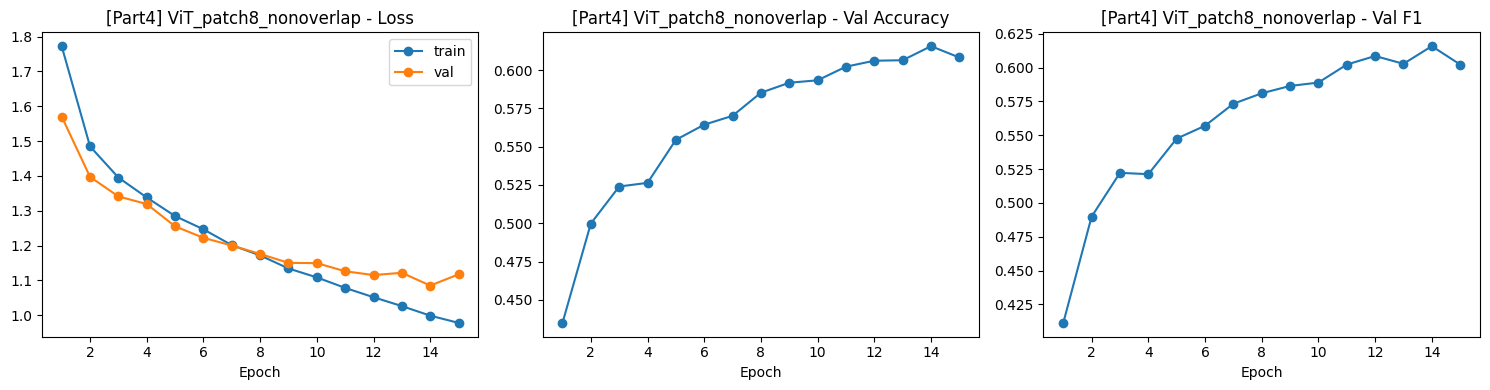

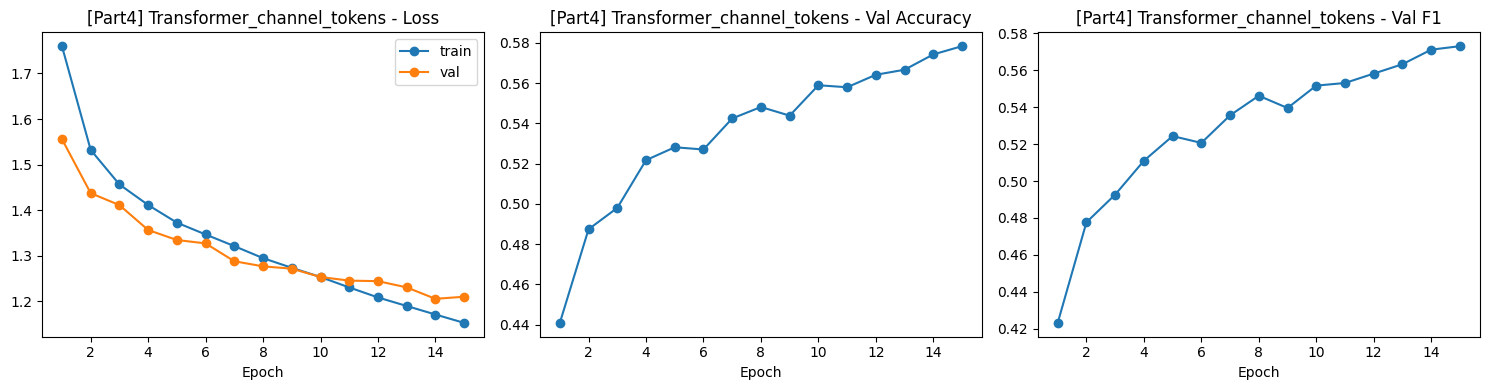

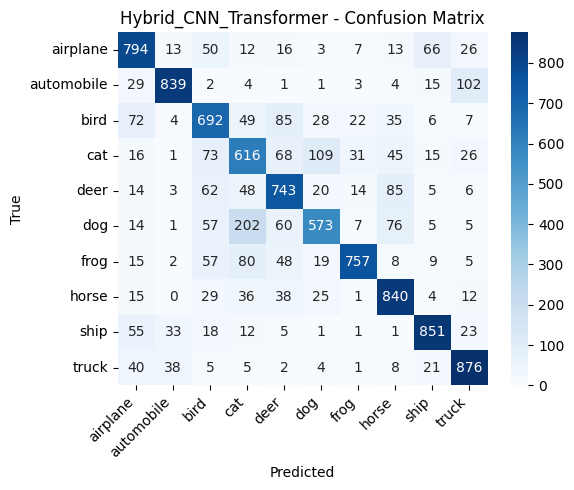

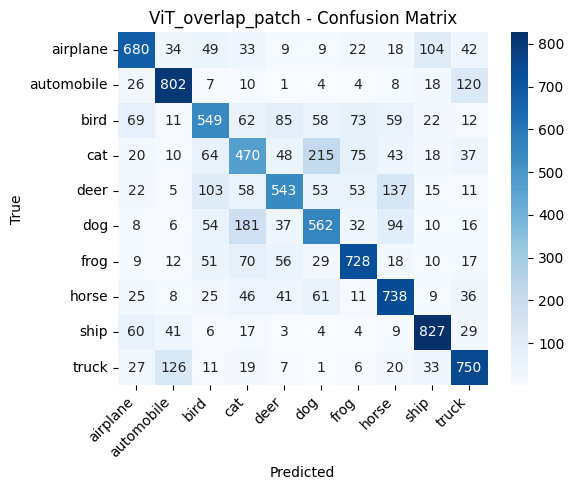

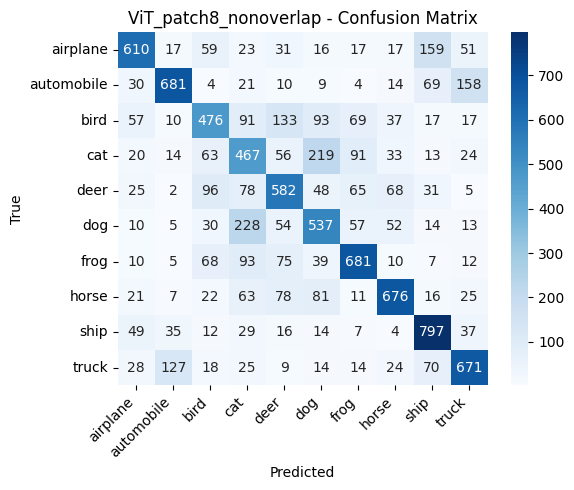

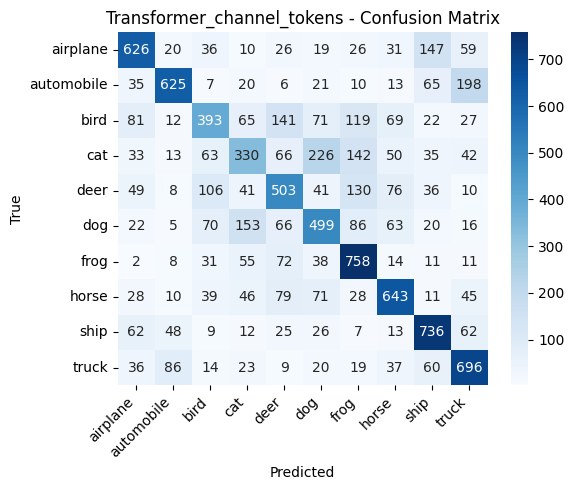

[Part4] Mô hình tốt nhất trên test: Hybrid_CNN_Transformer | loss=0.7032, acc=0.7581, train_time=654.37s
Nhận xét Part 4:
- Hybrid CNN + Transformer thường cho kết quả ổn định trên CIFAR-10 nhờ backbone CNN.
- Overlap patch tăng số token, có thể cải thiện đặc trưng nhưng tốn chi phí train.
- Channel token là cách embed theo chiều C (khác H*W), dùng để so sánh hướng biểu diễn.


In [15]:
plot_histories(part4_histories, title_prefix="[Part4] ")
plot_confusion_matrices(part4_conf_mats, CLASS_NAMES)

best_row_p4 = part4_df.iloc[0]
print(
    f"[Part4] Mô hình tốt nhất trên test: {best_row_p4['Model']} | "
    f"loss={best_row_p4['Loss']:.4f}, acc={best_row_p4['Accuracy']:.4f}, "
    f"train_time={best_row_p4['Train time (s)']:.2f}s"
 )

print("Nhận xét Part 4:")
print("- Hybrid CNN + Transformer thường cho kết quả ổn định trên CIFAR-10 nhờ backbone CNN.")
print("- Overlap patch tăng số token, có thể cải thiện đặc trưng nhưng tốn chi phí train.")
print("- Channel token là cách embed theo chiều C (khác H*W), dùng để so sánh hướng biểu diễn.")